In [1]:
# Radon Forecast — SVR (Support Vector Regression)

# Установка зависимостей
!pip install -q scikit-learn matplotlib pandas seaborn

In [2]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import json
import os

In [3]:
# --- Загрузка и подготовка данных ---
def load_and_prepare_data(filepath):
    print("Загрузка и подготовка данных...")
    df = pd.read_csv(filepath, sep=';', decimal=',', encoding='latin-1')
    df['Datetime'] = pd.to_datetime(df['Datetime'], format="%d.%m.%Y %H:%M")
    df.set_index('Datetime', inplace=True)
    df = df.sort_index().interpolate(method='time')
    return df

In [4]:
def split_and_scale_data(df, target_column):
    X = df.drop(columns=[target_column])
    y = df[target_column]
    train_size = int(len(df) * 0.8)
    X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
    y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, y_train, y_test, X.columns

In [5]:
# --- Поиск гиперпараметров ---
def tune_svr(X_train_scaled, y_train):
    param_dist = {
        'C': [0.1, 1, 10, 100],
        'epsilon': [0.01, 0.1, 1],
        'kernel': ['rbf', 'linear']
    }
    tscv = TimeSeriesSplit(n_splits=5)
    search = RandomizedSearchCV(SVR(), param_distributions=param_dist,
                                n_iter=10, cv=tscv, scoring='neg_mean_squared_error', random_state=42)
    print("Поиск лучших параметров SVR...")
    search.fit(X_train_scaled, y_train)
    return search

In [6]:
# --- Основной скрипт ---
df = load_and_prepare_data("/content/data.csv")
TARGET = 'Radon (Bq.m3)'
X_train_scaled, X_test_scaled, y_train, y_test, feature_names = split_and_scale_data(df, TARGET)

Загрузка и подготовка данных...


In [7]:
search = tune_svr(X_train_scaled, y_train)
best_model = search.best_estimator_
y_pred = best_model.predict(X_test_scaled)

Поиск лучших параметров SVR...


In [8]:
# --- Метрики ---
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Лучшие параметры SVR: {search.best_params_}")
print(f"MSE: {mse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}")

Лучшие параметры SVR: {'kernel': 'rbf', 'epsilon': 0.01, 'C': 0.1}
MSE: 98926400.32, MAE: 7528.08, R2: -0.34


In [9]:
metrics = {
    "best_params": search.best_params_,
    "test_mse": mse,
    "test_mae": mae,
    "test_r2": r2
}
with open("svr_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

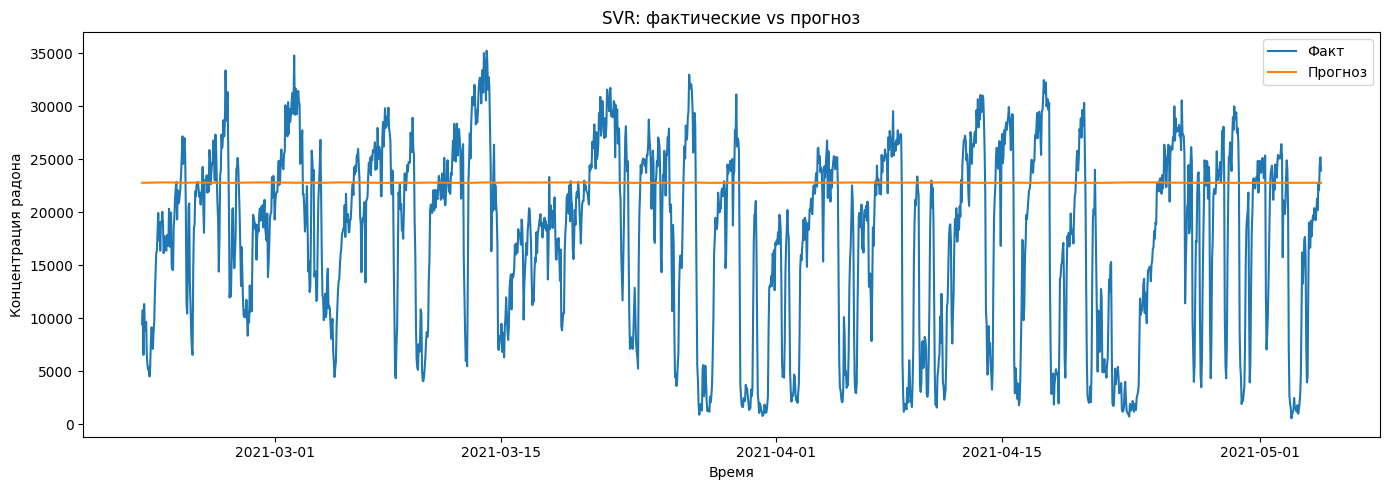

In [10]:
# --- Визуализация прогноза ---
plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test, label='Факт')
plt.plot(y_test.index, y_pred, label='Прогноз')
plt.title("SVR: фактические vs прогноз")
plt.xlabel("Время")
plt.ylabel("Концентрация радона")
plt.legend()
plt.tight_layout()
plt.savefig("svr_forecast.jpeg")
plt.show()

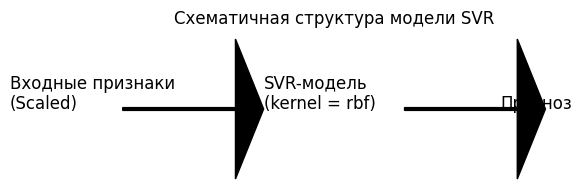

In [11]:
# --- Визуализация схемы модели ---
plt.figure(figsize=(6, 2))
plt.axis('off')
plt.text(0.05, 0.5, 'Входные признаки\n(Scaled)', fontsize=12)
plt.arrow(0.25, 0.5, 0.2, 0, head_width=0.05, head_length=0.05, fc='k', ec='k')
plt.text(0.5, 0.5, 'SVR-модель\n(kernel = ' + str(search.best_params_['kernel']) + ')', fontsize=12)
plt.arrow(0.75, 0.5, 0.2, 0, head_width=0.05, head_length=0.05, fc='k', ec='k')
plt.text(0.92, 0.5, 'Прогноз', fontsize=12)
plt.title("Схематичная структура модели SVR")
plt.savefig("svr_structure.jpeg")
plt.show()